In [7]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neighbors import NearestNeighbors

%matplotlib inline

In [8]:
# Normal data
X1 = np.random.randn(100, 2)

# Outliers
X2 = np.random.uniform(low=-5, high=5, size=(15, 2))

# Combine
X = np.vstack((X1, X2))

In [9]:
k = 10
nbrs = NearestNeighbors(n_neighbors=k)
nbrs.fit(X)

distances, indices = nbrs.kneighbors(X)

In [10]:
# Sum of distances to neighbors (connectivity)
cof_score = np.sum(distances, axis=1)

In [12]:
threshold = np.percentile(cof_score, 90)

outliers = X[cof_score > threshold]
normal = X[cof_score <= threshold]

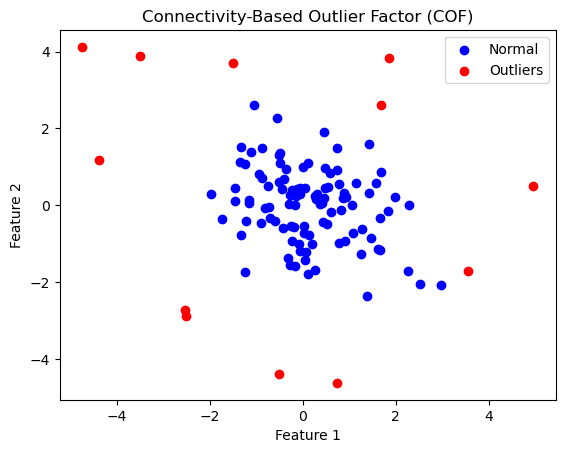

In [19]:
plt.scatter(normal[:,0], normal[:,1], color='blue', label='Normal')
plt.scatter(outliers[:,0], outliers[:,1], color='red', label='Outliers')

plt.title("Connectivity-Based Outlier Factor (COF)")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.legend()

plt.show()